# 📊 01 — Exploratory Data Analysis (EDA)

**E-Commerce Customer Behavior Analysis & Hybrid Recommendation System**

**AIE 323 — Data Mining | Spring 2025/2026**

---

## Objectives
- Understand the structure and quality of all 3 datasets
- Identify patterns, distributions, and anomalies
- Guide the data cleaning and feature engineering steps

In [1]:
# ============================================================
# Imports & Configuration
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Paths
DATA_RAW = Path('../data/raw')
FIGURES = Path('../results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

print('✅ Libraries loaded')

✅ Libraries loaded


---
## 1. Dataset 1: Online Retail II (Tabular)
**Source:** UCI ML Repository | **Type:** Transactional data | **~1M rows**

In [2]:
# ============================================================
# 1.1 Load Online Retail II
# ============================================================
retail_path = DATA_RAW / 'online_retail' / 'online_retail_II.xlsx'

# Load both sheets
df_retail_y1 = pd.read_excel(retail_path, sheet_name='Year 2009-2010')
df_retail_y2 = pd.read_excel(retail_path, sheet_name='Year 2010-2011')
df_retail = pd.concat([df_retail_y1, df_retail_y2], ignore_index=True)

print(f'Shape: {df_retail.shape}')
print(f'Date Range: {df_retail["InvoiceDate"].min()} → {df_retail["InvoiceDate"].max()}')
print(f'Unique Customers: {df_retail["Customer ID"].nunique()}')
print(f'Unique Products: {df_retail["StockCode"].nunique()}')
print(f'Unique Countries: {df_retail["Country"].nunique()}')
df_retail.head()

Shape: (1067371, 8)
Date Range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Unique Customers: 5942
Unique Products: 5305
Unique Countries: 43


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# ============================================================
# 1.2 Data Types & Info
# ============================================================
print('--- Data Types ---')
print(df_retail.dtypes)
print(f'\n--- Memory Usage: {df_retail.memory_usage(deep=True).sum() / 1024**2:.1f} MB ---')

--- Data Types ---
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

--- Memory Usage: 207.3 MB ---


--- Missing Values ---
             Missing  Percentage
Customer ID   243007       22.77
Description     4382        0.41


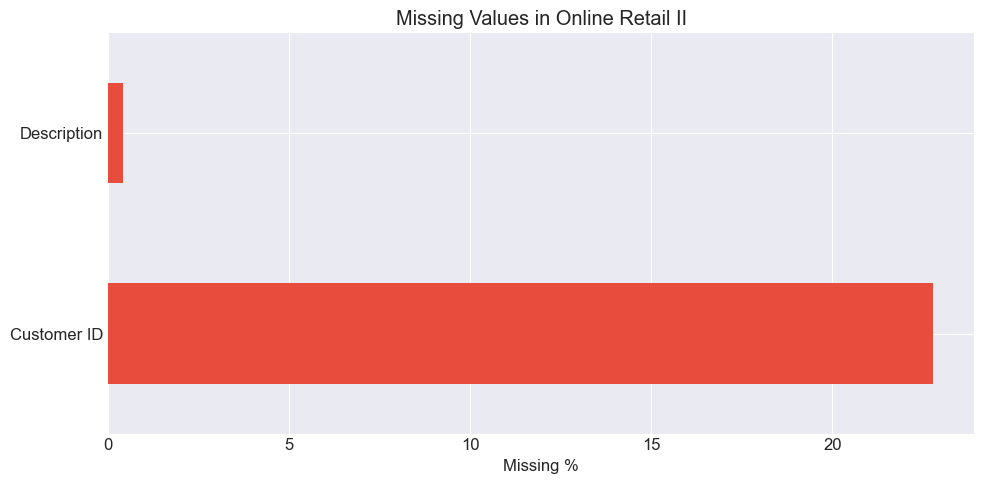

In [4]:
# ============================================================
# 1.3 Missing Values Analysis
# ============================================================
missing = df_retail.isnull().sum()
missing_pct = (missing / len(df_retail) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=False)

print('--- Missing Values ---')
print(missing_df)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['Percentage'].plot(kind='barh', color='#e74c3c', ax=ax)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values in Online Retail II')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_missing_values.png', dpi=150)
plt.show()

In [5]:
# ============================================================
# 1.4 Descriptive Statistics
# ============================================================
print('--- Numeric Columns ---')
df_retail.describe().round(2)

--- Numeric Columns ---


,Quantity,InvoiceDate,Price,Customer ID
count,1067371.00,1067371,1067371.00,824364.00
mean,9.94,2011-01-02 21:13:55.394029,4.65,15324.64
min,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-07-09 09:46:00,1.25,13975.00
50%,3.00,2010-12-07 15:28:00,2.10,15255.00
75%,10.00,2011-07-22 10:23:00,4.15,16797.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,172.71,NaN,123.55,1697.46


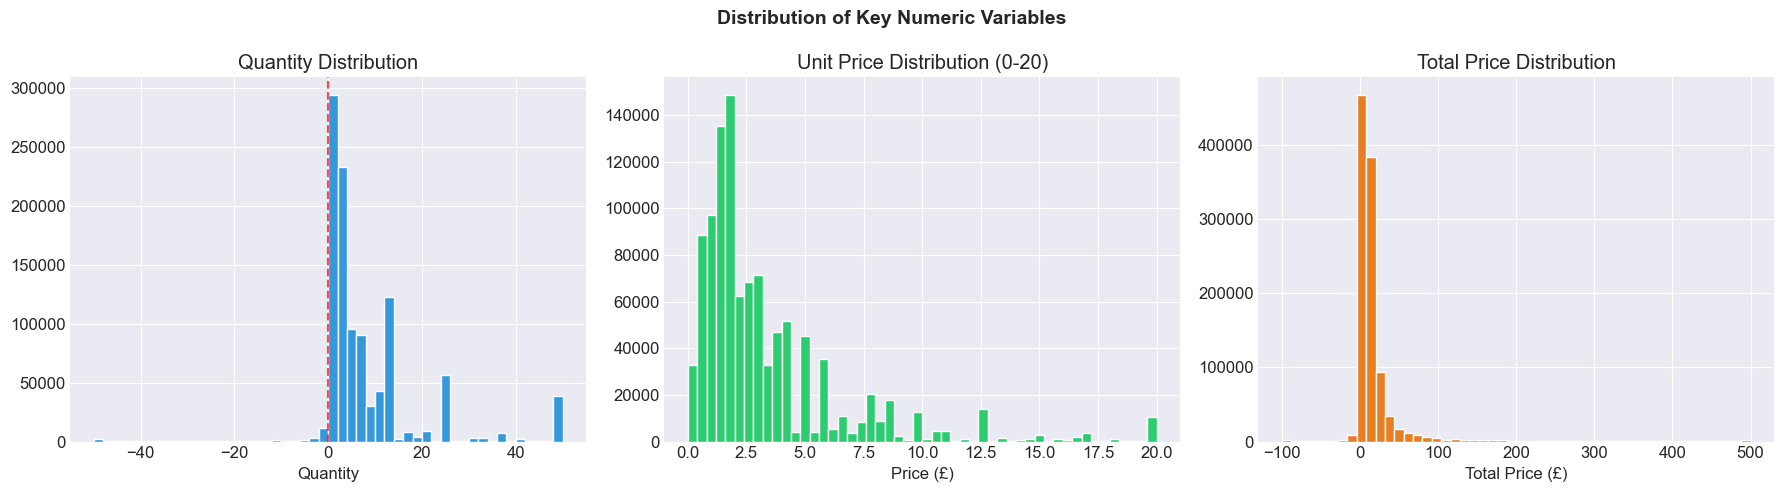

In [6]:
# ============================================================
# 1.5 Distribution Plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Quantity distribution (clip outliers for visibility)
df_retail['Quantity'].clip(-50, 50).hist(bins=50, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Quantity Distribution')
axes[0].set_xlabel('Quantity')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.7)

# Price distribution (clip outliers)
df_retail['Price'].clip(0, 20).hist(bins=50, ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Unit Price Distribution (0-20)')
axes[1].set_xlabel('Price (£)')

# TotalPrice
df_retail['TotalPrice'] = df_retail['Quantity'] * df_retail['Price']
df_retail['TotalPrice'].clip(-100, 500).hist(bins=50, ax=axes[2], color='#e67e22', edgecolor='white')
axes[2].set_title('Total Price Distribution')
axes[2].set_xlabel('Total Price (£)')

plt.suptitle('Distribution of Key Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_distributions.png', dpi=150)
plt.show()

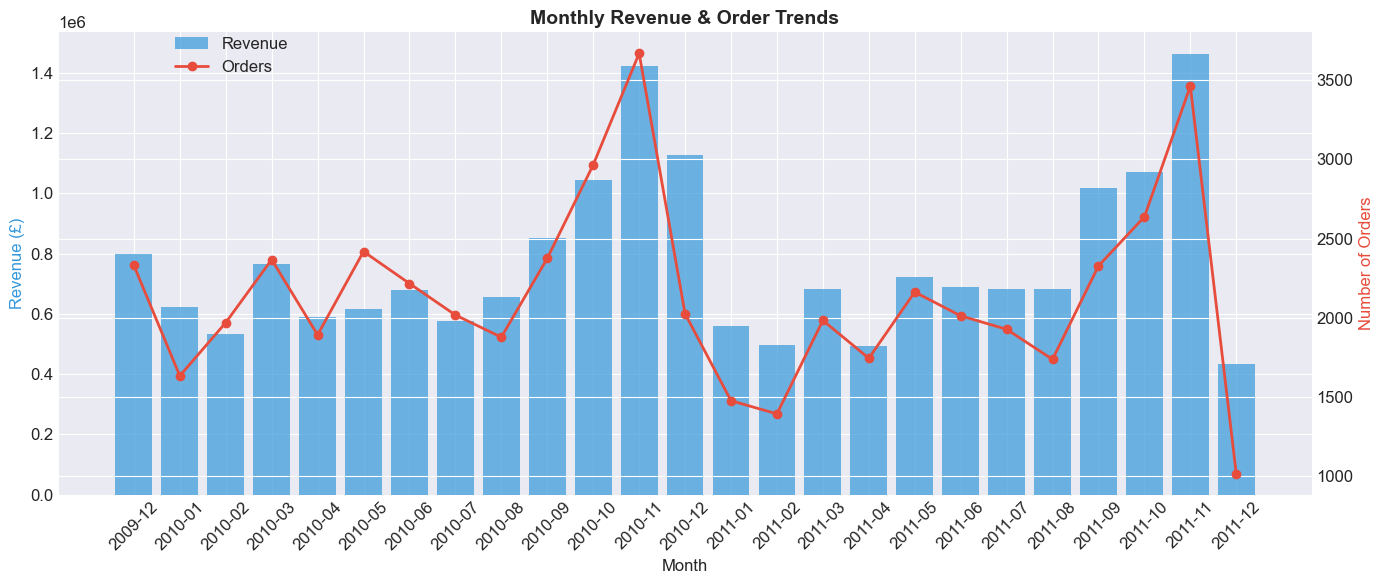

In [7]:
# ============================================================
# 1.6 Orders Over Time (Monthly)
# ============================================================
df_retail['YearMonth'] = df_retail['InvoiceDate'].dt.to_period('M')
monthly = df_retail.groupby('YearMonth').agg(
    Orders=('Invoice', 'nunique'),
    Revenue=('TotalPrice', 'sum'),
    Customers=('Customer ID', 'nunique')
).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))
color1, color2 = '#3498db', '#e74c3c'

ax1.bar(monthly['YearMonth'], monthly['Revenue'], color=color1, alpha=0.7, label='Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (£)', color=color1)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly['YearMonth'], monthly['Orders'], color=color2, marker='o', linewidth=2, label='Orders')
ax2.set_ylabel('Number of Orders', color=color2)

plt.title('Monthly Revenue & Order Trends', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.savefig(FIGURES / 'eda_monthly_trends.png', dpi=150)
plt.show()

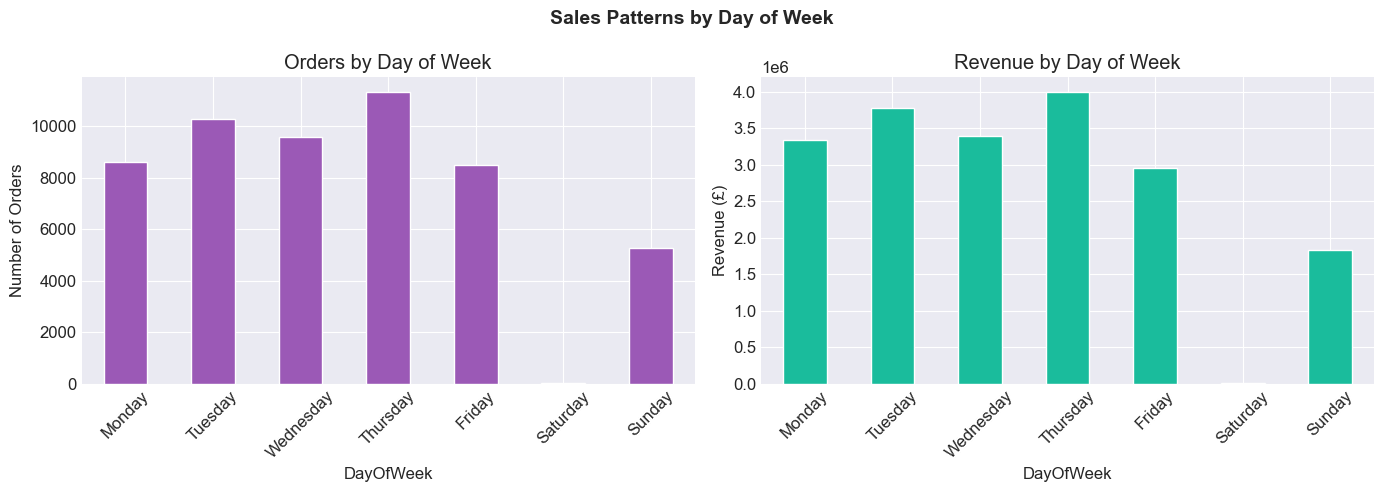

In [8]:
# ============================================================
# 1.7 Day of Week Analysis
# ============================================================
df_retail['DayOfWeek'] = df_retail['InvoiceDate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_stats = df_retail.groupby('DayOfWeek').agg(
    Orders=('Invoice', 'nunique'),
    Revenue=('TotalPrice', 'sum')
).reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
day_stats['Orders'].plot(kind='bar', ax=axes[0], color='#9b59b6', edgecolor='white')
axes[0].set_title('Orders by Day of Week')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=45)

day_stats['Revenue'].plot(kind='bar', ax=axes[1], color='#1abc9c', edgecolor='white')
axes[1].set_title('Revenue by Day of Week')
axes[1].set_ylabel('Revenue (£)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Sales Patterns by Day of Week', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_day_of_week.png', dpi=150)
plt.show()

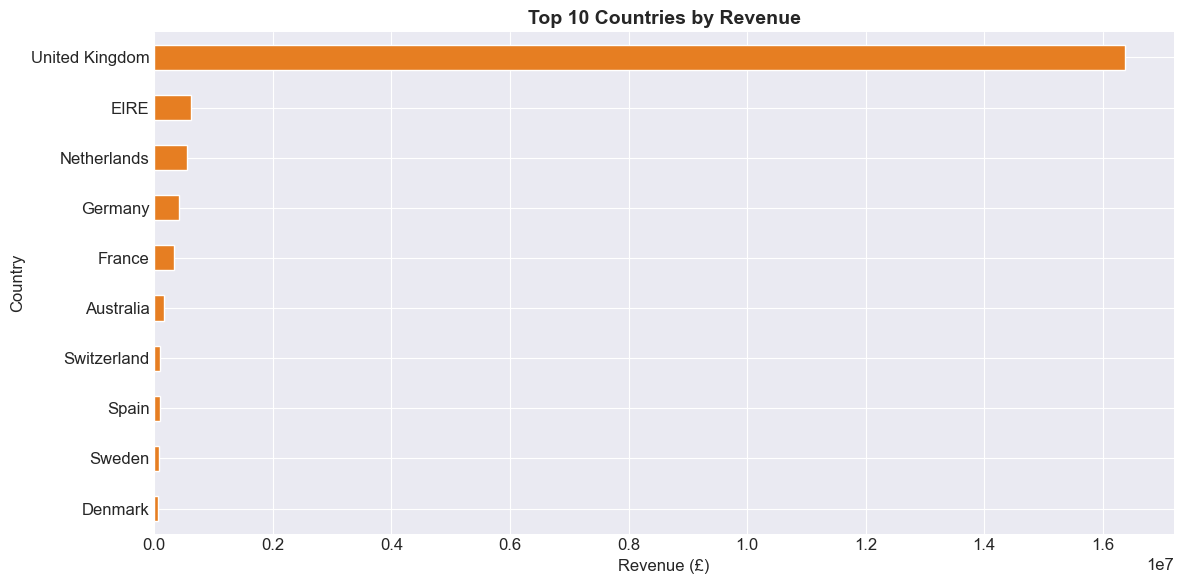

,Revenue,Customers,Orders
Country,,,
United Kingdom,1.638258e+07,5410,49108
EIRE,6.155196e+05,5,806
Netherlands,5.485249e+05,23,250
Germany,4.179886e+05,107,1095
France,3.281918e+05,95,746
Australia,1.671291e+05,15,117
Switzerland,9.972876e+04,22,123
Spain,9.185948e+04,41,188
Sweden,8.780942e+04,19,129


In [9]:
# ============================================================
# 1.8 Top 10 Countries by Revenue
# ============================================================
country_stats = df_retail.groupby('Country').agg(
    Revenue=('TotalPrice', 'sum'),
    Customers=('Customer ID', 'nunique'),
    Orders=('Invoice', 'nunique')
).sort_values('Revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
country_stats['Revenue'].plot(kind='barh', color='#e67e22', edgecolor='white', ax=ax)
ax.set_xlabel('Revenue (£)')
ax.set_title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES / 'eda_top_countries.png', dpi=150)
plt.show()

country_stats

In [10]:
# ============================================================
# 1.9 Top 10 Products by Quantity Sold
# ============================================================
positive_retail = df_retail[df_retail['Quantity'] > 0]
top_products = positive_retail.groupby(['StockCode', 'Description']).agg(
    TotalQty=('Quantity', 'sum'),
    TotalRevenue=('TotalPrice', 'sum'),
    TimesOrdered=('Invoice', 'nunique')
).sort_values('TotalQty', ascending=False).head(10)

print('--- Top 10 Products ---')
top_products

--- Top 10 Products ---


,,TotalQty,TotalRevenue,TimesOrdered
StockCode,Description,,,
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,110249,25259.90,1021
85123A,WHITE HANGING HEART T-LIGHT HOLDER,96091,262931.16,5361
84879,ASSORTED COLOUR BIRD ORNAMENT,81817,132187.92,2808
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
85099B,JUMBO BAG RED RETROSPOT,78866,148823.92,3249
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
17003,BROCADE RING PURSE,71440,14959.19,457
21977,PACK OF 60 PINK PAISLEY CAKE CASES,56794,28490.98,1993
84991,60 TEATIME FAIRY CAKE CASES,54716,27404.22,2127


Cancellation Rate: 1.83%
Total Cancelled Transactions: 19,494
Total Normal Transactions: 1,047,877


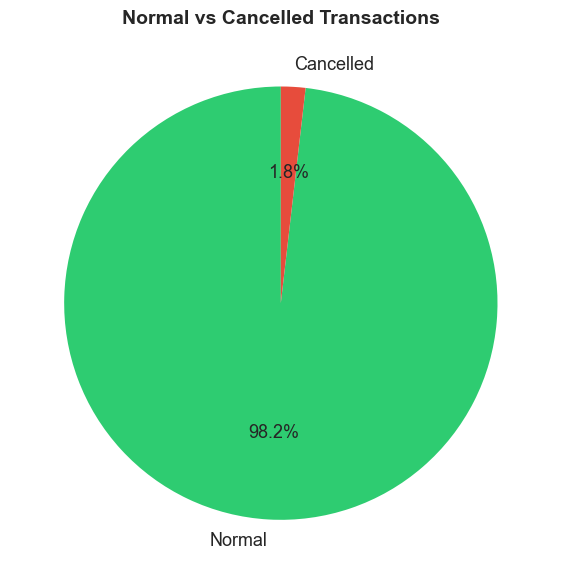

In [11]:
# ============================================================
# 1.10 Cancellation / Returns Analysis
# ============================================================
df_retail['IsCancelled'] = df_retail['Invoice'].astype(str).str.startswith('C')
cancel_rate = df_retail['IsCancelled'].mean() * 100

print(f'Cancellation Rate: {cancel_rate:.2f}%')
print(f'Total Cancelled Transactions: {df_retail["IsCancelled"].sum():,}')
print(f'Total Normal Transactions: {(~df_retail["IsCancelled"]).sum():,}')

# Pie chart
fig, ax = plt.subplots(figsize=(8, 6))
labels = ['Normal', 'Cancelled']
sizes = [(~df_retail['IsCancelled']).sum(), df_retail['IsCancelled'].sum()]
colors = ['#2ecc71', '#e74c3c']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, 
       textprops={'fontsize': 13})
ax.set_title('Normal vs Cancelled Transactions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_cancellation_rate.png', dpi=150)
plt.show()

---
## 2. Dataset 2: Women's Clothing Reviews (Hybrid: Text + Tabular)

In [12]:
# ============================================================
# 2.1 Load Reviews Dataset
# ============================================================
reviews_path = DATA_RAW / 'clothing_reviews'
# Try common filenames
for fname in ['Womens Clothing E-Commerce Reviews.csv', 'reviews.csv']:
    fpath = reviews_path / fname
    if fpath.exists():
        df_reviews = pd.read_csv(fpath)
        break
else:
    csv_files = list(reviews_path.glob('*.csv'))
    if csv_files:
        df_reviews = pd.read_csv(csv_files[0])
    else:
        print('❌ Reviews dataset not found. Please download from:')
        print('   https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews')
        print(f'   Extract to: {reviews_path}')
        df_reviews = None

if df_reviews is not None:
    print(f'Shape: {df_reviews.shape}')
    print(f'Columns: {list(df_reviews.columns)}')
    df_reviews.head()

Shape: (23486, 11)
Columns: ['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


In [13]:
# ============================================================
# 2.2 Reviews — Data Quality
# ============================================================
if df_reviews is not None:
    print('--- Data Types ---')
    print(df_reviews.dtypes)
    print(f'\n--- Missing Values ---')
    missing_r = df_reviews.isnull().sum()
    missing_r_pct = (missing_r / len(df_reviews) * 100).round(2)
    print(pd.DataFrame({'Missing': missing_r, '%': missing_r_pct})[missing_r > 0])
    print(f'\n--- Descriptive Stats ---')
    display(df_reviews.describe())

--- Data Types ---
Unnamed: 0                 int64
Clothing ID                int64
Age                        int64
Title                        str
Review Text                  str
Rating                     int64
Recommended IND            int64
Positive Feedback Count    int64
Division Name                str
Department Name              str
Class Name                   str
dtype: object

--- Missing Values ---
                 Missing      %
Title               3810  16.22
Review Text          845   3.60
Division Name         14   0.06
Department Name       14   0.06
Class Name            14   0.06

--- Descriptive Stats ---


,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


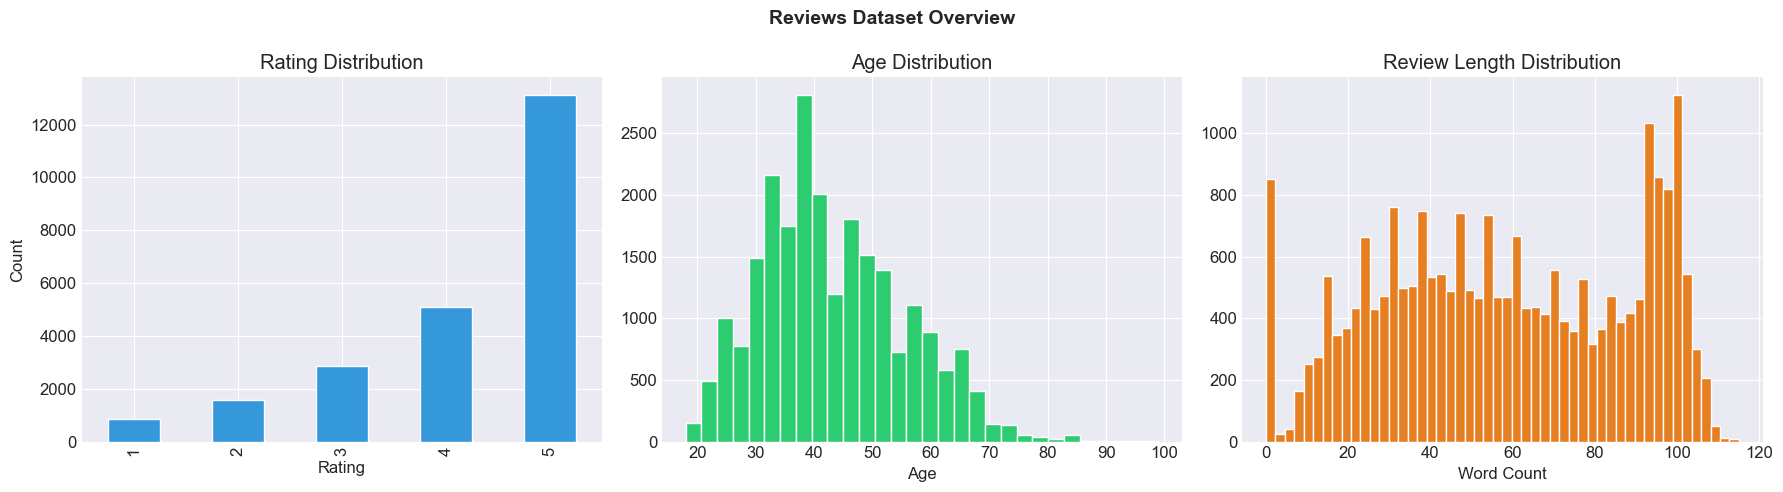

In [14]:
# ============================================================
# 2.3 Rating Distribution
# ============================================================
if df_reviews is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Rating distribution
    rating_col = 'Rating' if 'Rating' in df_reviews.columns else 'rating'
    if rating_col not in df_reviews.columns:
        for c in df_reviews.columns:
            if 'rating' in c.lower():
                rating_col = c
                break
    
    df_reviews[rating_col].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], color='#3498db', edgecolor='white'
    )
    axes[0].set_title('Rating Distribution')
    axes[0].set_xlabel('Rating')
    axes[0].set_ylabel('Count')
    
    # Age distribution
    age_col = 'Age' if 'Age' in df_reviews.columns else 'age'
    if age_col not in df_reviews.columns:
        for c in df_reviews.columns:
            if 'age' in c.lower():
                age_col = c
                break
    
    if age_col in df_reviews.columns:
        df_reviews[age_col].hist(bins=30, ax=axes[1], color='#2ecc71', edgecolor='white')
        axes[1].set_title('Age Distribution')
        axes[1].set_xlabel('Age')
    
    # Review length
    review_text_col = None
    for c in df_reviews.columns:
        if 'review' in c.lower() and 'text' in c.lower():
            review_text_col = c
            break
    if review_text_col is None:
        for c in df_reviews.columns:
            if 'review' in c.lower() and df_reviews[c].dtype == 'object':
                review_text_col = c
                break
    
    if review_text_col:
        df_reviews['ReviewLength'] = df_reviews[review_text_col].fillna('').str.split().str.len()
        df_reviews['ReviewLength'].hist(bins=50, ax=axes[2], color='#e67e22', edgecolor='white')
        axes[2].set_title('Review Length Distribution')
        axes[2].set_xlabel('Word Count')
    
    plt.suptitle('Reviews Dataset Overview', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / 'eda_reviews_distributions.png', dpi=150)
    plt.show()

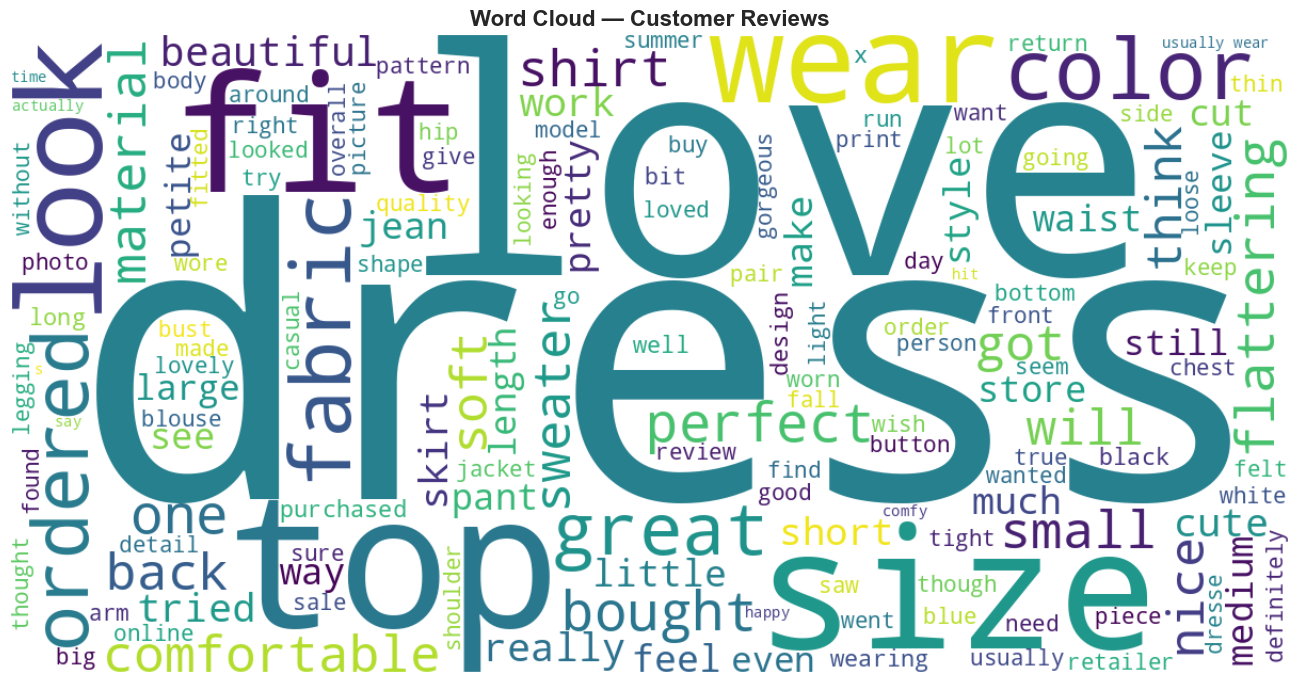

In [15]:
# ============================================================
# 2.4 Word Cloud of Reviews
# ============================================================
if df_reviews is not None and review_text_col:
    from wordcloud import WordCloud
    
    text = ' '.join(df_reviews[review_text_col].dropna().values)
    
    wc = WordCloud(
        width=1200, height=600, 
        background_color='white',
        colormap='viridis',
        max_words=150,
        contour_width=2
    ).generate(text)
    
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Word Cloud — Customer Reviews', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / 'eda_wordcloud.png', dpi=150)
    plt.show()

---
## 3. Dataset 3: Fashion MNIST (Image)
**Source:** Built into sklearn/keras | **Type:** 70K grayscale images (28×28) | **10 categories**

Categories: T-shirt/Top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle Boot

In [16]:
# ============================================================
# 3.1 Load Fashion MNIST
# ============================================================
from sklearn.datasets import fetch_openml

print('Loading Fashion MNIST from sklearn (this may take a minute)...')
fashion = fetch_openml('Fashion-MNIST', version=1, as_frame=True, parser='auto')
X_fashion = fashion.data
y_fashion = fashion.target.astype(int)

# Category labels
fashion_labels = {
    0: 'T-shirt/Top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle Boot'
}

print(f'Images: {X_fashion.shape[0]}')
print(f'Pixels per image: {X_fashion.shape[1]} (28×28)')
print(f'Categories: {len(fashion_labels)}')
print(f'\nClass Distribution:')
class_dist = y_fashion.map(fashion_labels).value_counts().sort_index()
print(class_dist)

Loading Fashion MNIST from sklearn (this may take a minute)...
Images: 70000
Pixels per image: 784 (28×28)
Categories: 10

Class Distribution:
class
Ankle Boot     7000
Bag            7000
Coat           7000
Dress          7000
Pullover       7000
Sandal         7000
Shirt          7000
Sneaker        7000
T-shirt/Top    7000
Trouser        7000
Name: count, dtype: int64


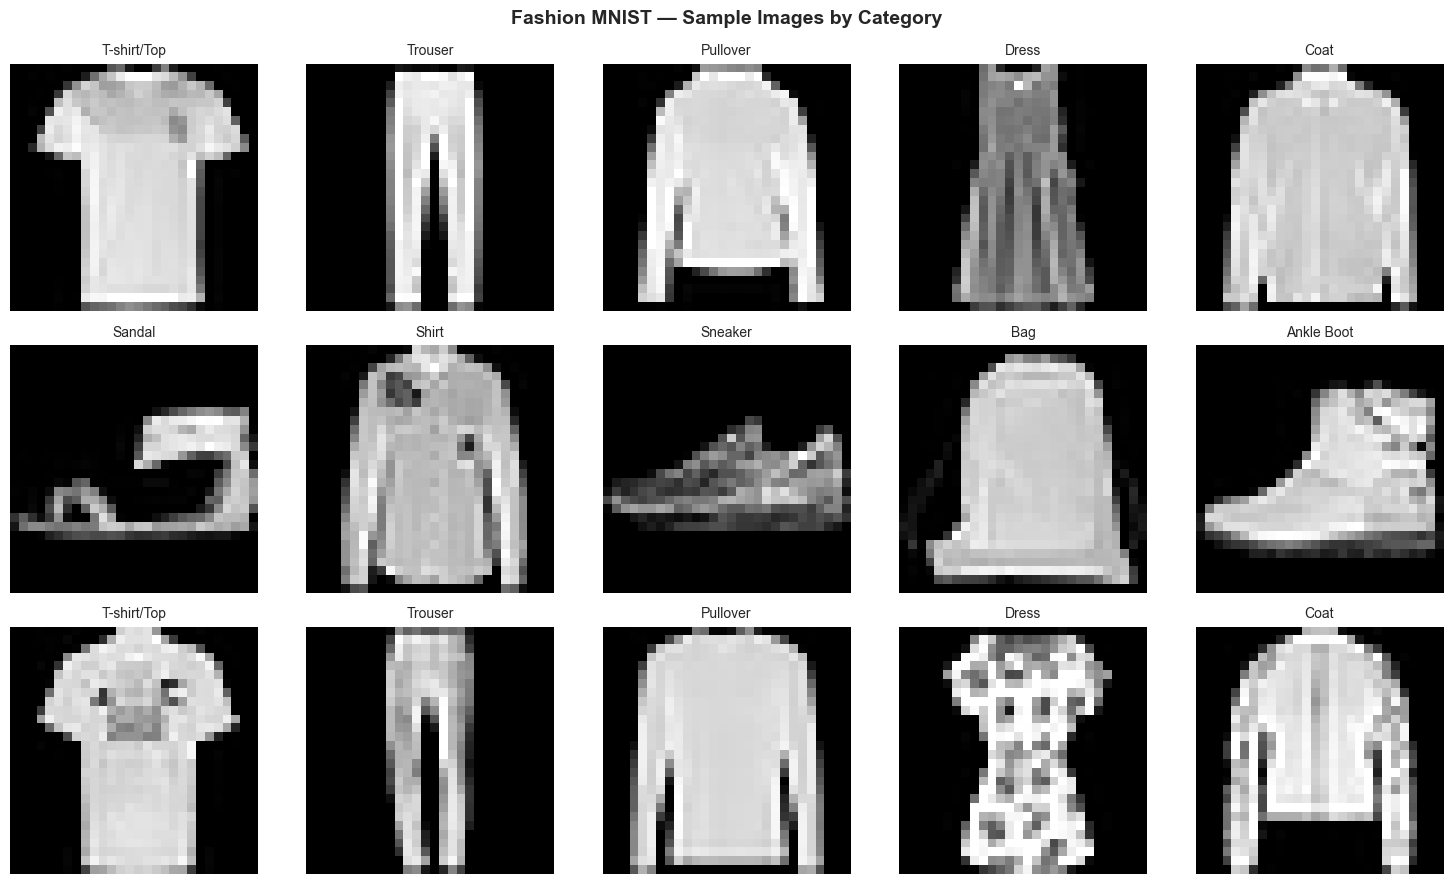

In [17]:
# ============================================================
# 3.2 Sample Images Grid (3x5 = 15 samples)
# ============================================================
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i, ax in enumerate(axes.flat):
    # Pick a random image from each category (cycle through)
    cat_id = i % 10
    cat_indices = y_fashion[y_fashion == cat_id].index
    idx = cat_indices[np.random.randint(len(cat_indices))]
    
    img = X_fashion.iloc[idx].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(fashion_labels[cat_id], fontsize=10)
    ax.axis('off')

plt.suptitle('Fashion MNIST — Sample Images by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_fashion_mnist_samples.png', dpi=150)
plt.show()

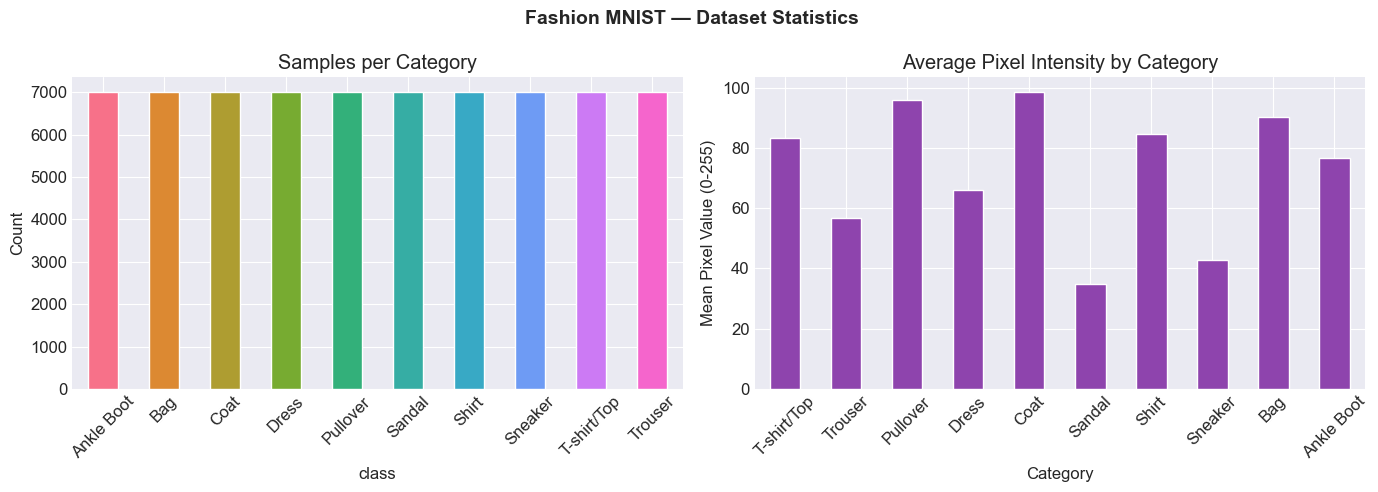

In [18]:
# ============================================================
# 3.3 Category Distribution & Pixel Statistics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_dist.plot(kind='bar', ax=axes[0], color=sns.color_palette('husl', 10), edgecolor='white')
axes[0].set_title('Samples per Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Average pixel intensity per category
avg_intensity = []
for cat_id in range(10):
    cat_mask = y_fashion == cat_id
    avg_val = X_fashion[cat_mask].mean().mean()
    avg_intensity.append({'Category': fashion_labels[cat_id], 'AvgPixel': avg_val})

intensity_df = pd.DataFrame(avg_intensity)
intensity_df.plot(x='Category', y='AvgPixel', kind='bar', ax=axes[1], 
                  color='#8e44ad', edgecolor='white', legend=False)
axes[1].set_title('Average Pixel Intensity by Category')
axes[1].set_ylabel('Mean Pixel Value (0-255)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Fashion MNIST — Dataset Statistics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_fashion_mnist_stats.png', dpi=150)
plt.show()

---
## 5. Cross-Dataset Summary

In [19]:
# ============================================================
# 5.1 Dataset Summary Table
# ============================================================
summary_data = []

# Online Retail
summary_data.append({
    'Dataset': 'Online Retail II',
    'Type': 'Tabular (XLSX)',
    'Rows': len(df_retail),
    'Columns': len(df_retail.columns),
    'Missing %': round(df_retail.isnull().mean().mean() * 100, 2),
    'Size (MB)': round(df_retail.memory_usage(deep=True).sum() / 1024**2, 1)
})

# Reviews
if df_reviews is not None:
    summary_data.append({
        'Dataset': 'Clothing Reviews',
        'Type': 'Hybrid (Text + Tabular)',
        'Rows': len(df_reviews),
        'Columns': len(df_reviews.columns),
        'Missing %': round(df_reviews.isnull().mean().mean() * 100, 2),
        'Size (MB)': round(df_reviews.memory_usage(deep=True).sum() / 1024**2, 1)
    })

# Fashion MNIST
summary_data.append({
    'Dataset': 'Fashion MNIST',
    'Type': 'Image (28×28 grayscale)',
    'Rows': len(X_fashion),
    'Columns': X_fashion.shape[1],
    'Missing %': 0.0,
    'Size (MB)': round(X_fashion.memory_usage(deep=True).sum() / 1024**2, 1)
})

summary_df = pd.DataFrame(summary_data)
print('\n📊 === DATASET SUMMARY ===')
summary_df


📊 === DATASET SUMMARY ===


,Dataset,Type,Rows,Columns,Missing %,Size (MB)
0,Online Retail II,Tabular (XLSX),1067371,12,1.93,240.0
1,Clothing Reviews,Hybrid (Text + Tabular),23486,12,1.67,9.7
2,Fashion MNIST,Image (28×28 grayscale),70000,784,0.00,418.7


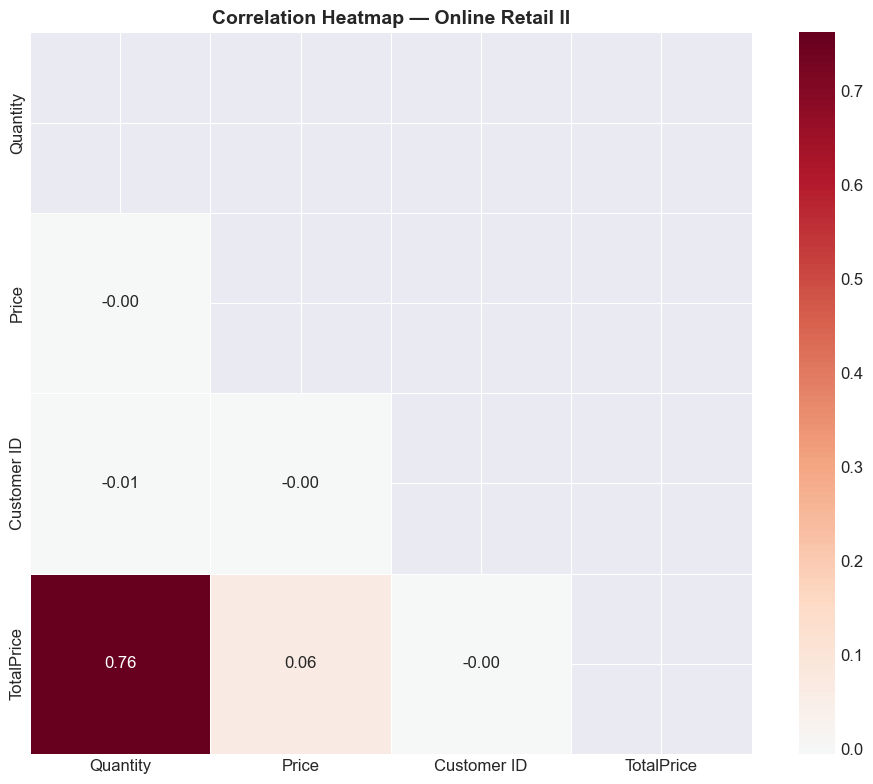

In [20]:
# ============================================================
# 5.2 Correlation Heatmap (Retail Numeric Features)
# ============================================================
numeric_cols = df_retail.select_dtypes(include=[np.number]).columns
corr = df_retail[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Online Retail II', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_correlation_heatmap.png', dpi=150)
plt.show()

---
## 6. Key Findings & Next Steps

### Key Findings:
1. **Missing Values:** Customer ID has significant missing values — needs to be dropped for customer-level analysis
2. **Cancellations:** There are cancelled orders (Invoice starts with 'C') — separate for returns analysis
3. **Outliers:** Quantity and Price have extreme values — need IQR filtering
4. **UK Dominant:** United Kingdom dominates revenue — consider separate analysis
5. **No Saturday Orders:** Retail shows no Saturday activity — business insight
6. **Fashion MNIST:** Balanced dataset (7,000 per class), suitable for multi-class CNN classification
7. **Reviews:** Review text available for NLP sentiment analysis, Age column for demographic insights

### Next Steps (ETL Pipeline):
- Remove null CustomerIDs
- Filter out cancellations/returns
- Handle outliers with IQR method
- Compute TotalPrice = Quantity × UnitPrice
- Feature engineering: RFM, DayOfWeek, IsWeekend
- Sentiment scoring on reviews
- Fashion MNIST processed in CNN notebook (06_Image_CNN.ipynb)